In [102]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt

In [103]:
loaded_data = datasets.fetch_openml('mnist_784', version=1, as_frame=False)
loaded_data

{'data': array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784)),
 'target': array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object),
 'frame': None,
 'categories': {'class': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']},
 'feature_names': ['pixel1',
  'pixel2',
  'pixel3',
  'pixel4',
  'pixel5',
  'pixel6',
  'pixel7',
  'pixel8',
  'pixel9',
  'pixel10',
  'pixel11',
  'pixel12',
  'pixel13',
  'pixel14',
  'pixel15',
  'pixel16',
  'pixel17',
  'pixel18',
  'pixel19',
  'pixel20',
  'pixel21',
  'pixel22',
  'pixel23',
  'pixel24',
  'pixel25',
  'pixel26',
  'pixel27',
  'pixel28',
  'pixel29',
  'pixel30',
  'pixel31',
  'pixel32',
  'pixel33',
  'pixel34',
  'pixel35',
  'pixel36',
  'pixel37',
  'pixel38',
  'pixel39',
  'pixel40',
  'pixel41',
  'pixel42',
  'pixel43',
  'pixel44',


In [104]:
softmax = lambda Z: (E := np.exp(Z)) / np.sum(E, axis=1, keepdims=True)

In [105]:
sigma = lambda X, W: X @ W

In [106]:
grad = lambda X, S, T: X.T @ (S - T) / S.shape[0]

In [107]:
x_entropy = lambda T, S: -np.sum(T * np.log(S + 1e-8)) / S.shape[0]

In [108]:
forward = lambda X, W: softmax(sigma(X,W))

In [109]:
backward = lambda  X, W, S, T, lr: W - lr * grad(X, S, T)

In [110]:
X, y = loaded_data.data, loaded_data.target
X = X.astype(np.float32)
X /= 255.0

In [111]:
np.sqrt(X[0].shape[0])

np.float64(28.0)

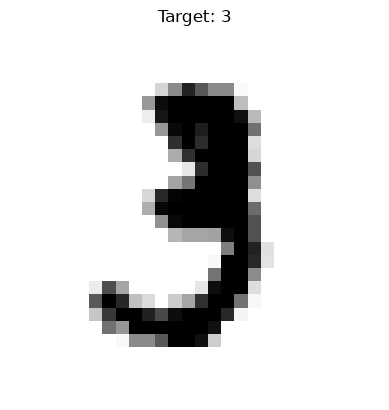

In [112]:
plt.imshow(np.reshape(X[10], (28, 28)), cmap='binary')
plt.axis('off')
plt.title(f"Target: {y[10]}")
plt.show()

In [113]:
num_epoch = 1000
W = np.random.rand(784, 10) * 0.01
T = np.eye(10)[y.astype(int)] # TODO one hot
num_data = X.shape[0]
split = int(num_data * .8)
shuffle = np.random.permutation(num_data)
X_train, T_train = X[shuffle[:split]], T[shuffle[:split]]
X_test, T_test = X[shuffle[split:]], T[shuffle[split:]]
lr = 0.1
snapshot_delay = 10

In [114]:
for epoch in range(num_epoch):
    # forward
    S_train = softmax(sigma(X_train, W))
    if epoch % snapshot_delay == 0: 
        train_loss = x_entropy(T_train, S_train[:split])
        S_test = softmax(sigma(X_test, W))
        test_loss = x_entropy(T_test, S_test)
        print("Epoch: ", epoch)
        print("Train loss: ", train_loss)
        print("Test loss: ", test_loss)
    # backward
    W -= lr * grad(X_train, S_train, T_train)

Train loss:  2.3023327284644517
Test loss:  2.30221935121532
Train loss:  1.5430029885718832
Test loss:  1.5453740876512394
Train loss:  1.1821749902078136
Test loss:  1.186145088539184
Train loss:  0.9894631382153655
Test loss:  0.9940792141484653
Train loss:  0.8718704678962425
Test loss:  0.876750036607201
Train loss:  0.7926297861241518
Test loss:  0.7976107681096659
Train loss:  0.735360758880825
Test loss:  0.7403710837301042
Train loss:  0.6918288874365978
Test loss:  0.6968366389521464
Train loss:  0.6574714824555233
Test loss:  0.6624636873722802
Train loss:  0.6295600259247908
Test loss:  0.6345329084197184
Train loss:  0.6063615934188742
Test loss:  0.611315853963572
Train loss:  0.5867211792990467
Test loss:  0.5916596255343782
Train loss:  0.5698381169476109
Test loss:  0.574764450802931
Train loss:  0.555139036150678
Test loss:  0.5600572302293608
Train loss:  0.5422019811794037
Test loss:  0.54711596316805
Train loss:  0.5307091362190148
Test loss:  0.5356226368075323
Tr

In [115]:
X_test_pred = np.argmax(softmax(sigma(X_test, W)), axis=1)

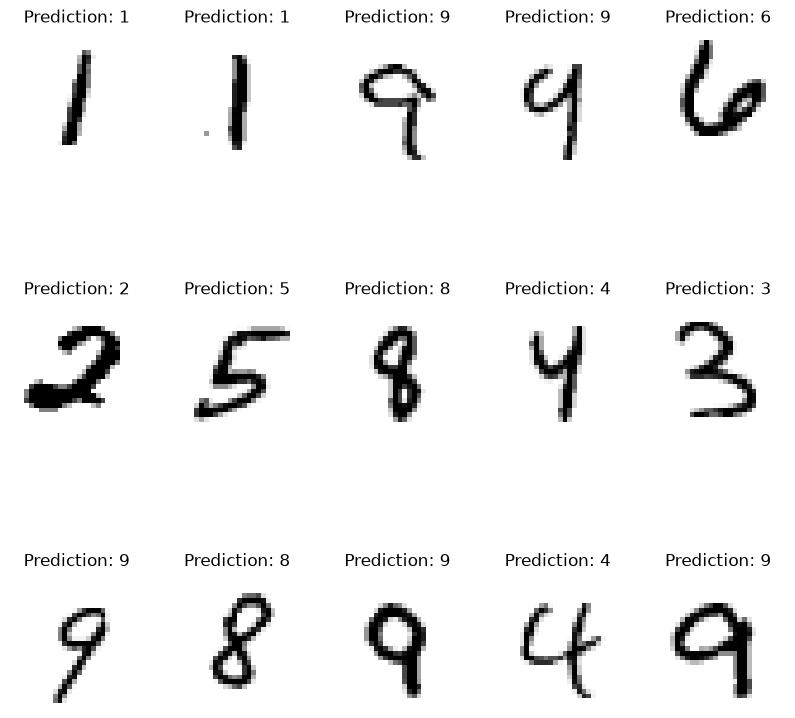

In [119]:


fig, ax = plt.subplots(3,5, figsize=[10, 10])
for i in range(15):
    ax[i//5, i%5].imshow(np.reshape(X_test[i], (28, 28)), cmap='binary')
    ax[i//5, i%5].axis('off')
    ax[i//5, i%5].set_title(f"Prediction: {X_test_pred[i]}")